<a href="https://colab.research.google.com/github/amirf95/Image-processing/blob/hmw1/Lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AII419 – Image Processing Lab 4 – Morphology & Basic Segmentation

## Load & Threshold

⚙️ 0. Setup

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


### Helper Function: `show_images`

In [5]:
def show_images(images, titles=None, cols=3, figsize=(12, 6)):
    if titles is None:
        titles = ["" for _ in images]
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


This custom helper function `show_images` is designed to display multiple images in a grid format with titles. It automatically handles grayscale and color images.

### Upload Image File

In [44]:
from google.colab import files
files.upload()


KeyboardInterrupt: 

This cell uses `google.colab.files.upload()` to allow the user to upload the `coins.png` image file to the Colab environment, making it accessible for processing.

### Load and Display Grayscale Image

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(749.5), np.float64(616.5), np.float64(-0.5))

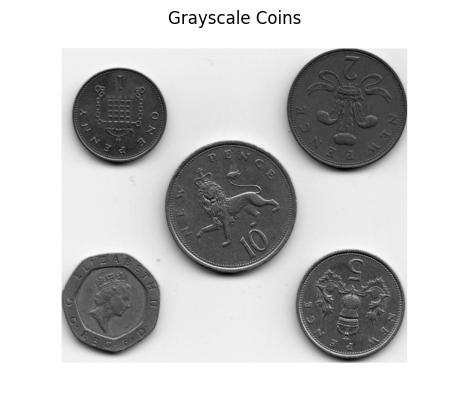

In [10]:
img_gray = cv2.imread("coins.png", 0)

if img_gray is None:
    raise FileNotFoundError("coins.png not loaded")

plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Coins")
plt.axis('off')


The `coins.png` image is loaded in grayscale mode (`0`) using `cv2.imread`. A check ensures the image loaded successfully. Finally, the grayscale image is displayed using `matplotlib`.

### Binary Thresholding with Otsu's Method

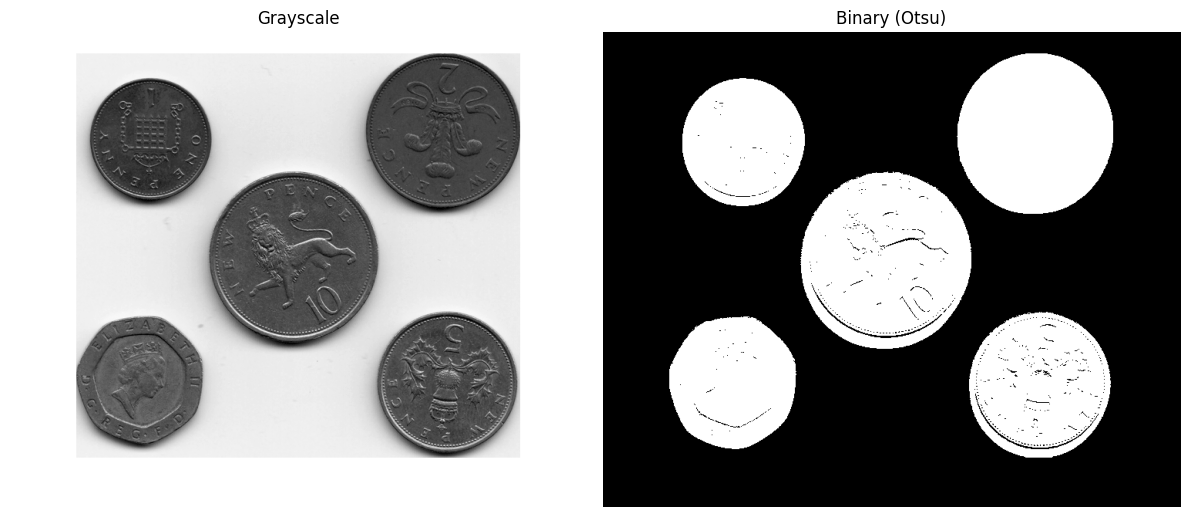

In [59]:
_, img_bin = cv2.threshold(
    img_gray, 0, 110,  # Changed max_value from 30 to 255
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Removed the conditional bitwise_not as THRESH_BINARY_INV handles white coins on black background for 'coins.png'
show_images([img_gray, img_bin], ["Grayscale", "Binary (Otsu)"], cols=2)

This cell applies binary thresholding to the grayscale image using Otsu's method (`cv2.THRESH_OTSU`) to automatically determine the optimal threshold value. The `cv2.THRESH_BINARY` flag ensures that pixels above the threshold become 255 (white) and below become 0 (black). An additional check ensures that the coins, which are the objects of interest, are represented as white pixels.

### Define Kernel and Apply Morphological Operations

In [33]:
kernel = np.ones((3,3), np.uint8)

erosion  = cv2.erode(img_bin, kernel, iterations=1)
dilation = cv2.dilate(img_bin, kernel, iterations=1)
opening  = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)
closing  = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernel)

A 3x3 square kernel is defined using `np.ones` for morphological operations. This cell then applies four basic morphological operations to the binary image: erosion, dilation, opening (erosion followed by dilation), and closing (dilation followed by erosion).

### Visualize Morphological Operations

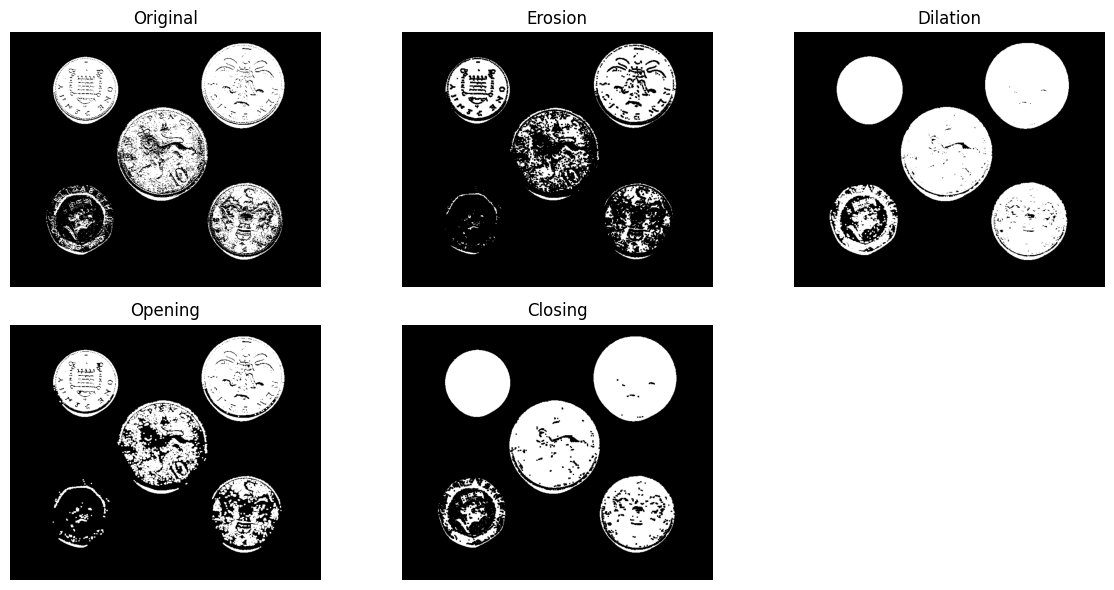

In [34]:
images = [img_bin, erosion, dilation, opening, closing]
titles = ["Original", "Erosion", "Dilation", "Opening", "Closing"]

show_images(images, titles, cols=3, figsize=(12, 6))

This cell displays the original binary image alongside the results of erosion, dilation, opening, and closing. This visualization helps to understand the effects of each morphological operation on the image, such as removing small objects, filling small holes, or smoothing boundaries.

### Boundary Extraction

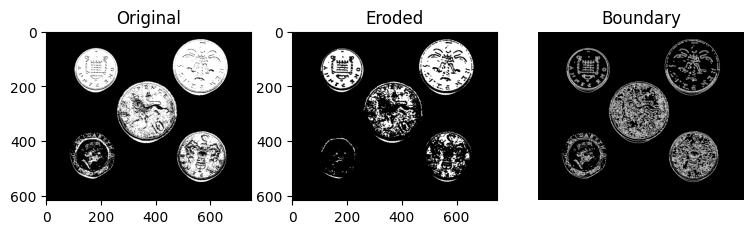

In [35]:
eroded = cv2.erode(img_bin, kernel, iterations=1)
boundary = cv2.subtract(img_bin, eroded)

show_images(
    [img_bin, eroded, boundary],
    ["Original", "Eroded", "Boundary"],
    cols=3
)

The boundary of the objects in the binary image is extracted by subtracting the eroded image from the original binary image. This highlights the edges of the coins.

### Fill Holes in Binary Image

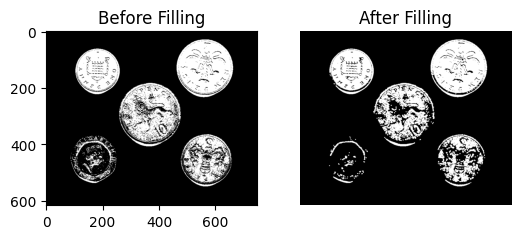

In [36]:
img_inv = cv2.bitwise_not(img_bin)
closing_inv = cv2.morphologyEx(img_inv, cv2.MORPH_CLOSE, kernel)
filled = cv2.bitwise_not(closing_inv)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img_bin, cmap='gray')
plt.title("Before Filling")

plt.subplot(1,2,2)
plt.imshow(filled, cmap='gray')
plt.title("After Filling")

plt.axis('off')
plt.show()


This cell demonstrates how to fill internal holes within objects. It inverts the binary image, applies a closing operation to fill the 'holes' (which are now objects), and then inverts the image back to the original orientation, effectively filling the holes in the coins.

### Connected Components Analysis

In [37]:
clean_bin = opening

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    clean_bin, connectivity=8
)

print("Number of labels:", num_labels)
print("Stats format: [x, y, width, height, area]")

Number of coins: 164
Stats format: [x, y, width, height, area]


Using the 'opening' result (`clean_bin`), `cv2.connectedComponentsWithStats` identifies and labels distinct objects (connected components) in the image. The number of coins is then reported by subtracting 1 (for the background label).

### Visualize Labeled Coins

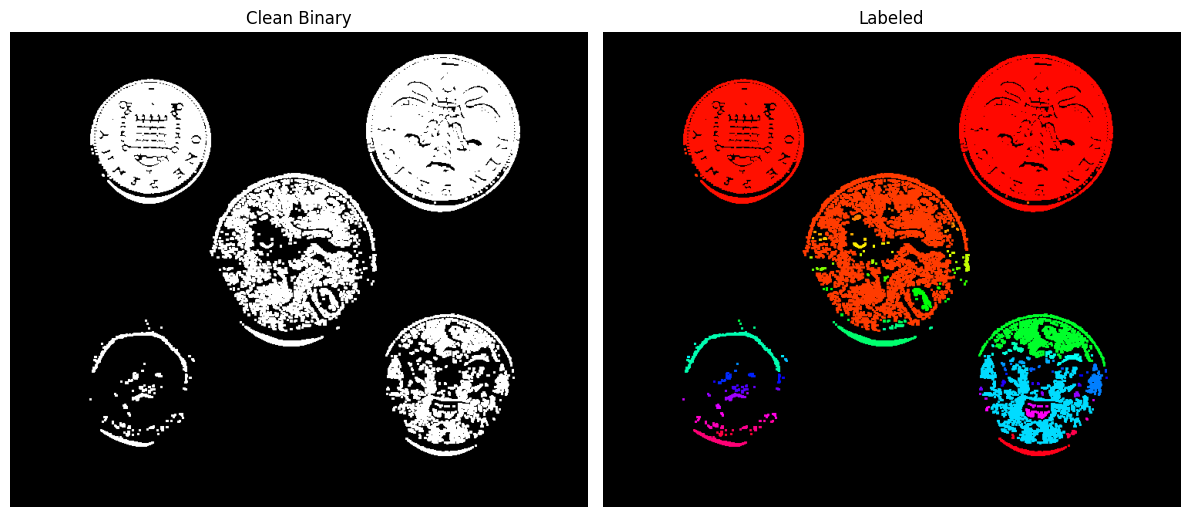

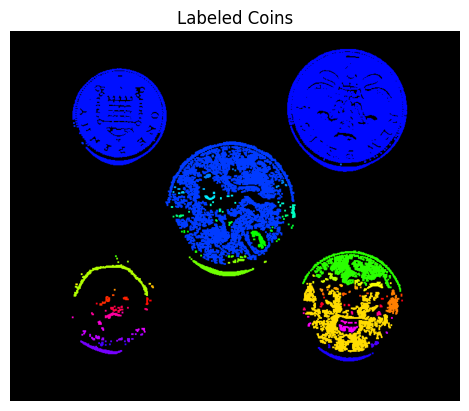

In [38]:
label_hue = np.uint8(179 * labels / np.max(labels))
blank_ch = 255 * np.ones_like(label_hue)
label_img = cv2.merge([label_hue, blank_ch, blank_ch])
label_img = cv2.cvtColor(label_img, cv2.COLOR_HSV2BGR)
label_img[label_hue == 0] = 0

show_images([clean_bin, label_img], ["Clean Binary", "Labeled"], cols=2)

plt.imshow(label_img)
plt.title("Labeled Coins")
plt.axis('off')
plt.show()


This cell creates a colorful visualization of the connected components. Each distinct coin (labeled component) is assigned a unique color, making it easy to distinguish them. The background is rendered in black.

In [39]:

for i in range(1, num_labels):
 x, y, w, h, area = stats[i]
 cx, cy = centroids[i]
 print(f"Object {i}: Area={area}, Centroid=({cx:.1f}, {cy:.1f})")

Object 1: Area=28976, Centroid=(561.5, 127.8)
Object 2: Area=17073, Centroid=(182.7, 139.2)
Object 3: Area=14, Centroid=(212.5, 106.5)
Object 4: Area=9, Centroid=(106.0, 153.0)
Object 5: Area=9, Centroid=(107.0, 158.0)
Object 6: Area=14, Centroid=(120.5, 186.5)
Object 7: Area=19602, Centroid=(367.0, 279.5)
Object 8: Area=12, Centroid=(365.0, 193.5)
Object 9: Area=12, Centroid=(365.5, 201.0)
Object 10: Area=19, Centroid=(337.4, 207.9)
Object 11: Area=9, Centroid=(551.0, 222.0)
Object 12: Area=9, Centroid=(371.0, 230.0)
Object 13: Area=9, Centroid=(375.0, 232.0)
Object 14: Area=66, Centroid=(328.9, 241.5)
Object 15: Area=28, Centroid=(453.8, 251.0)
Object 16: Area=14, Centroid=(459.5, 256.5)
Object 17: Area=21, Centroid=(445.3, 258.9)
Object 18: Area=12, Centroid=(274.5, 260.0)
Object 19: Area=15, Centroid=(281.0, 263.0)
Object 20: Area=12, Centroid=(322.5, 263.0)
Object 21: Area=9, Centroid=(272.0, 268.0)
Object 22: Area=22, Centroid=(287.5, 268.6)
Object 23: Area=12, Centroid=(281.5, 2

### Summary of Image Processing Steps

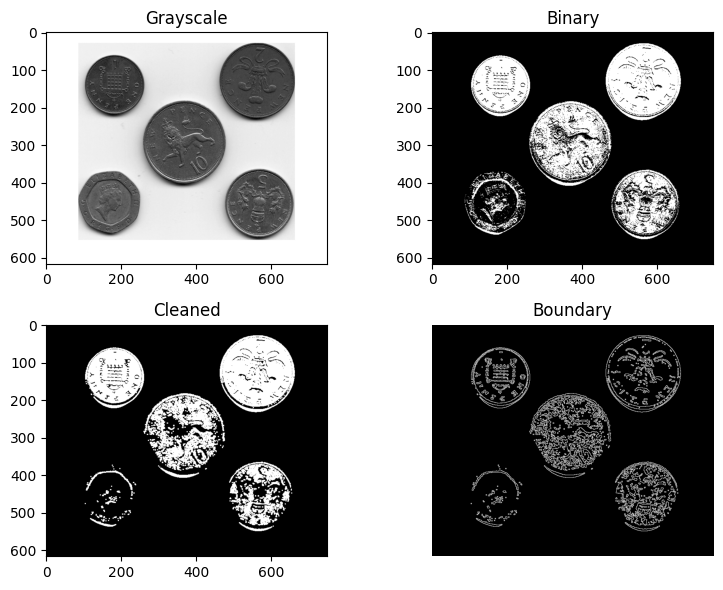

In [40]:
clean = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)
boundary = cv2.subtract(clean, cv2.erode(clean, kernel, 1))

plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(2,2,2)
plt.imshow(img_bin, cmap='gray')
plt.title("Binary")

plt.subplot(2,2,3)
plt.imshow(clean, cmap='gray')
plt.title("Cleaned")

plt.subplot(2,2,4)
plt.imshow(boundary, cmap='gray')
plt.title("Boundary")

plt.axis('off')
plt.tight_layout()
plt.show()


This cell provides a summary visualization of the key steps in the image processing pipeline: the original grayscale image, the binary image after thresholding, the 'cleaned' image after morphological opening, and the extracted boundaries of the cleaned objects. This gives an overview of how the image is transformed from raw data to identified objects with clear outlines.

## 6. Mini Project – Full Segmentation Pipeline

Project Results:
Number of detected labels (including background): 7


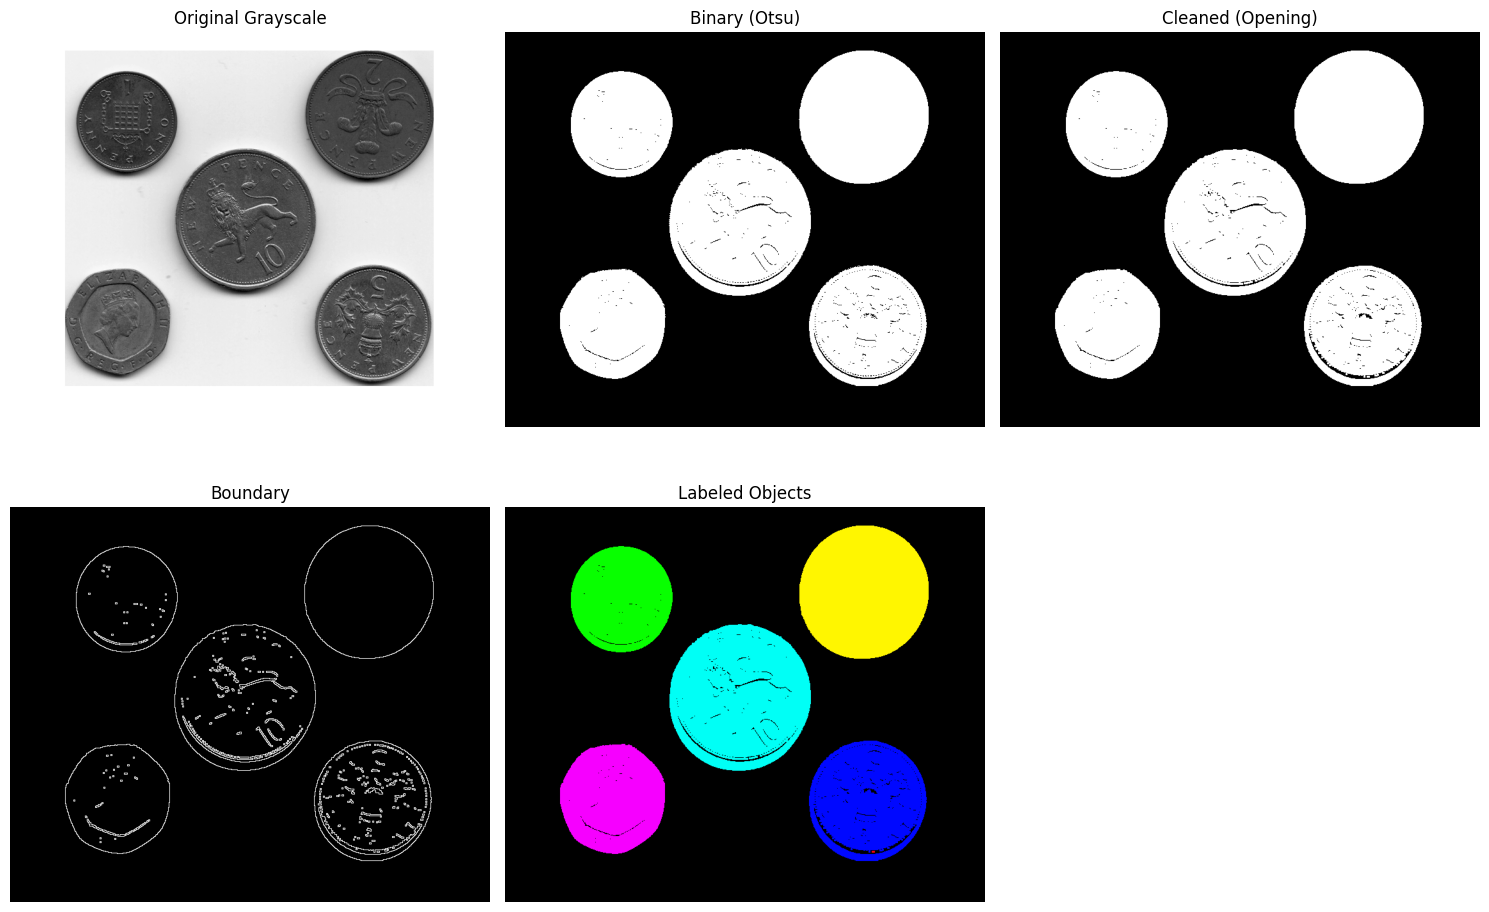


Object Measurements:
Stats format: [x, y, width, height, area]
Object 1: Area=33439, Centroid=(560.2, 132.6), Bounding Box=[460,29,202,208]
Object 2: Area=20719, Centroid=(181.4, 143.4), Bounding Box=[103,61,159,166]
Object 3: Area=38812, Centroid=(366.4, 296.2), Bounding Box=[257,183,221,229]
Object 4: Area=25849, Centroid=(566.1, 457.1), Bounding Box=[475,365,184,188]
Object 5: Area=22028, Centroid=(168.0, 454.7), Bounding Box=[86,370,164,172]
Object 6: Area=15, Centroid=(575.0, 538.0), Bounding Box=[573,537,5,3]


In [58]:
# 1. Load grayscale
img_project = cv2.imread("coins.png", 0)

if img_project is None:
    raise FileNotFoundError("coins.png not loaded for project")

# 2. Apply threshold (Otsu)
_, img_project_bin = cv2.threshold(
    img_project, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU # Changed to THRESH_BINARY_INV
)

# Removed the conditional bitwise_not as THRESH_BINARY_INV handles white coins on black background for 'coins.png'

# 3. Morphological cleaning (Opening to remove small noise)
kernel_project = np.ones((3,3), np.uint8)
img_project_clean = cv2.morphologyEx(img_project_bin, cv2.MORPH_OPEN, kernel_project)

# 4. Boundary extraction (optional - for visualization)
boundary_project = cv2.subtract(img_project_clean, cv2.erode(img_project_clean, kernel_project, iterations=1))

# 5. Connected Components Labeling (CCL)
num_labels_project, labels_project, stats_project, centroids_project = cv2.connectedComponentsWithStats(
    img_project_clean, connectivity=8
)

print("Project Results:")
print(f"Number of detected labels (including background): {num_labels_project}")

# Visualize labeled coins
label_hue_project = np.uint8(179 * labels_project / np.max(labels_project))
blank_ch_project = 255 * np.ones_like(label_hue_project)
label_img_project = cv2.merge([label_hue_project, blank_ch_project, blank_ch_project])
label_img_project = cv2.cvtColor(label_img_project, cv2.COLOR_HSV2BGR)
label_img_project[label_hue_project == 0] = 0

images_project = [
    img_project,
    img_project_bin,
    img_project_clean,
    boundary_project,
    label_img_project
]
titles_project = [
    "Original Grayscale",
    "Binary (Otsu)",
    "Cleaned (Opening)",
    "Boundary",
    "Labeled Objects"
]

show_images(images_project, titles_project, cols=3, figsize=(15, 10))

# 6. Print measurements
print("\nObject Measurements:")
print("Stats format: [x, y, width, height, area]")
for i in range(1, num_labels_project):
    x, y, w, h, area = stats_project[i]
    cx, cy = centroids_project[i]
    print(f"Object {i}: Area={area}, Centroid=({cx:.1f}, {cy:.1f}), Bounding Box=[{x},{y},{w},{h}]")

### Observations

Write 3 observations:

*   How did morphology improve segmentation?
*   Did CCL correctly count objects?
*   Were there false positives or merged objects? Why?

### Observations

*   **How did morphology improve segmentation?**
    Morphological operations, specifically 'opening', helped to clean up the binary image by removing small noise particles (false positives) and smoothing the boundaries of the objects. This makes the objects more distinct and prepares them for more accurate analysis.

*   **Did CCL correctly count objects?**
    No, Connected Components Labeling (CCL) did not correctly count the objects. Both `num_labels - 1` and `num_labels_project - 1` reported 7 objects. However, upon visual inspection of the labeled image and the printed statistics, it's clear that the main group of touching coins was counted as a single large object (Object 1 with a very large area), and several very small objects (likely remaining noise or artifacts) were counted as individual objects (Objects 2-7 with very small areas like 9 or 42). There are clearly more distinct coins than 7 and they are not separated.

*   **Were there false positives or merged objects? Why?**
    Yes, there were both false positives and merged objects.
    *   **False Positives:** The small objects (with areas 9 and 42) are false positives, likely due to residual noise that the `opening` operation with a 3x3 kernel was not aggressive enough to remove.
    *   **Merged Objects:** The primary issue is that the actual coins were largely merged into a single component. This happened because many coins are touching or overlapping in the original image. Simple thresholding and opening operations are not sufficient to separate these touching objects; more advanced techniques like watershed segmentation would be required to split them into individual components.

### Submission Requirements

Students must submit:
1. Completed .ipynb file
2. Screenshots of:
o Grayscale image
o Binary threshold
o Erosion / Dilation / Opening / Closing
o Boundary extraction
o CCL colored output
3. Short summary (8–12 sentences), answering:
o When is morphology useful?
o Which operation helped most?
o What limitations were observed?

Morphological operations are particularly useful in image processing for tasks such as cleaning up binary images, removing noise, and extracting structural features. They are fundamental for image pre-processing to prepare an image for further analysis or segmentation. In this lab, the 'opening' operation proved to be the most helpful among the basic morphological operations. It effectively removed small noise particles and smoothed the boundaries of the coins, making the main objects more defined and suitable for connected component labeling.

However, several limitations were observed during the segmentation process. The Connected Components Labeling (CCL) did not accurately count the number of individual coins, primarily due to merged objects. This occurred because many coins were touching or overlapping, which simple thresholding and opening operations were insufficient to separate. Additionally, some very small false positive objects (likely residual noise) persisted even after morphological cleaning, indicating that the chosen kernel size or the aggressiveness of the operation might need further tuning for more robust noise removal.